In [11]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# access to the data

In [12]:
import numpy as np
import pandas as pd

import os
import cv2

In [6]:
import os
print(os.getcwd())

c:\Users\Lenovo\Desktop\GUVI_2026\Project\3


In [8]:
data_dir = "./files/garbage_classification/"

classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

images = []
labels = []


for label, category in enumerate(classes):
    path = os.path.join(data_dir, category)
    
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        
        img = cv2.imread(img_path)
        img =  cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))             # initially it was (384, 512)
        
        images.append(img)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

In [5]:
X.shape, y.shape

((2527, 224, 224, 3), (2527,))

In [6]:
X.dtype, y.dtype

(dtype('uint8'), dtype('int64'))

In [58]:
# import matplotlib.pyplot as plt

# plt.imshow(X[-1])

In [8]:
np.unique(y)

array([0, 1, 2, 3, 4, 5])

In [7]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3, 4, 5]), array([403, 501, 410, 594, 482, 137]))

# Preprocessing

## Data Augmentation (oversampling)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

In [10]:
trash_class = 5
trash_images = X[y == trash_class]

In [11]:
trash_images.shape

(137, 224, 224, 3)

In [12]:
target_count = 500
current_count = len(trash_images)
needed = target_count - current_count

aug_images = []
aug_labels = []

i = 0
while i < needed:
    img = trash_images[np.random.randint(0, current_count)]
    img = img.reshape((1,) + img.shape)

    aug_iter = datagen.flow(img, batch_size=1)
    aug_img = next(aug_iter)[0].astype('uint8')

    aug_images.append(aug_img)
    aug_labels.append(trash_class)

    i += 1

In [13]:
X_aug = np.concatenate([X, np.array(aug_images)])
y_aug = np.concatenate([y, np.array(aug_labels)])

np.unique(y_aug, return_counts=True)

(array([0, 1, 2, 3, 4, 5]), array([403, 501, 410, 594, 482, 500]))

In [14]:
# import matplotlib.pyplot as plt

# plt.imshow(X_aug[-1])

## datatype conversiont (int - float)

In [15]:
X_aug.dtype

dtype('uint8')

In [16]:
X_aug = X_aug.astype('float32')

In [17]:
X_aug.dtype

dtype('float32')

## Normalize data

In [18]:
X_aug = X_aug/255

# Train, Val, Test

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X_aug, y_aug, test_size=0.3, stratify=y_aug, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=1)


In [ ]:
import joblib

joblib.dump((X_train, y_train), 'split_data/train_data.pkl')
joblib.dump((X_val, y_val), 'split_data/val_data.pkl')
joblib.dump((X_test, y_test), 'split_data/test_data.pkl')

In [15]:
X_train, y_train = joblib.load('split_data/train_data.pkl')
X_val, y_val = joblib.load('split_data/val_data.pkl')
X_test, y_test = joblib.load('split_data/test_data.pkl')

# Model

## Base model

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam, Adadelta

In [22]:
model = Sequential([
    Input(shape=(224, 224, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')    
])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 110, 110, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 53, 53, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,152,134 (42.54 MB)

 Trainable params: 11,152,134 (42.54 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer= 'Adadelta',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
# history = 
model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.1720 - loss: 1.8005 - val_accuracy: 0.2818 - val_loss: 1.7753
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.1962 - loss: 1.7793 - val_accuracy: 0.2309 - val_loss: 1.7681
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.2091 - loss: 1.7740 - val_accuracy: 0.2194 - val_loss: 1.7638
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.2383 - loss: 1.7640 - val_accuracy: 0.2217 - val_loss: 1.7592
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.2244 - loss: 1.7575 - val_accuracy: 0.2148 - val_loss: 1.7550
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.2210 - loss: 1.7589 - val_accuracy: 0.2309 - val_loss: 1.7517
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.2412 - loss: 1.7508 - val_accuracy: 0.2171 - val_loss: 1.7484
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.2378 - loss: 1.7546 - val_accuracy: 0.2309 - val_lo

In [26]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.3641 - loss: 1.6842
Test Accuracy: 0.3640553057193756


### save and the model

In [ ]:
model.save('base_model.keras')

In [3]:
from tensorflow.keras.models import load_model

model_1 = load_model('base_model.keras')

In [54]:
test_loss, test_acc = model_1.evaluate(X_test, y_test)

test_acc

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.3571 - loss: 1.6879


0.3571428656578064

In [ ]:
y_pred_probs = model_1.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

   cardboard       0.86      0.10      0.18        60
       glass       0.45      0.07      0.12        75
       metal       0.00      0.00      0.00        62
       paper       0.27      0.97      0.42        89
     plastic       0.57      0.18      0.27        73
       trash       0.60      0.60      0.60        75

    accuracy                           0.36       434
   macro avg       0.46      0.32      0.26       434
weighted avg       0.45      0.36      0.28       434



In [23]:
# model_1.predict(X_test[0].reshape(1, 224, 224, 3))

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, normalize='true')

print(pd.DataFrame(cm, index = classes, columns=classes))

           cardboard     glass  metal     paper   plastic     trash
cardboard   0.100000  0.000000    0.0  0.716667  0.000000  0.183333
glass       0.000000  0.066667    0.0  0.760000  0.093333  0.080000
metal       0.016129  0.064516    0.0  0.758065  0.048387  0.112903
paper       0.000000  0.011236    0.0  0.966292  0.000000  0.022472
plastic     0.000000  0.013699    0.0  0.753425  0.178082  0.054795
trash       0.000000  0.000000    0.0  0.400000  0.000000  0.600000


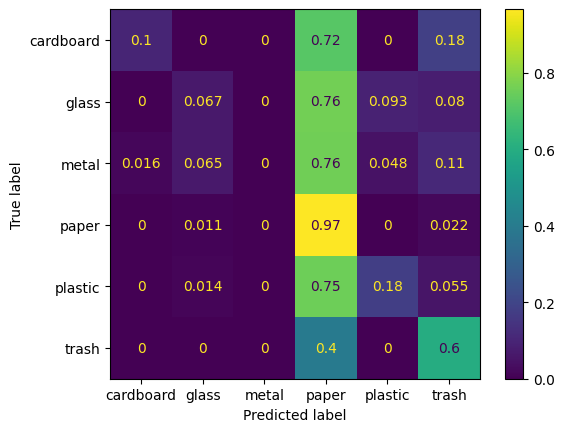

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.show()

# Transfer Learning (Pretrained model)

## ResNet50

50 layers

It was introduced by researchers at Microsoft Research and won the ImageNet Large Scale Visual Recognition Challenge 2015.

In [ ]:
# ResNet50, MobileNetV2, EfficientNetB0, inceptionnV3, ResNet101     -> transform learning

1)
solve under fitting

In [39]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten
from tensorflow.keras.optimizers import Adam, Adadelta

In [42]:
# load the pretrain model

p_model = ResNet50(
    weights='imagenet',   # pretrained on ImageNet
    include_top=False,    # remove original classifier
    input_shape=(224, 224, 3)
)

In [43]:
# Freeze Base Layers

for layer in p_model.layers:
    layer.trainable = False

# Keep learned features (edges, textures, shapes)  
# Train only our classifier  
# will not update the weights while training

In [44]:
model = Sequential([
    p_model,
    GlobalAveragePooling2D(),               # pooling + flatten
    
    Dense(256, activation='relu'),          # ann
    Dropout(0.5),                           # dropout
    
    Dense(6, activation='softmax')          # output layer (6 classes)
])

In [45]:
# compile

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy', # label encoder
    metrics=['accuracy']
)

In [ ]:
# train model

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 418s 6s/step - accuracy: 0.1760 - loss: 2.1027 - val_accuracy: 0.2055 - val_loss: 1.7759
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 393s 6s/step - accuracy: 0.1967 - loss: 1.9046 - val_accuracy: 0.2009 - val_loss: 1.7571
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 357s 6s/step - accuracy: 0.2066 - loss: 1.8199 - val_accuracy: 0.2564 - val_loss: 1.7434
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 348s 5s/step - accuracy: 0.2066 - loss: 1.7741 - val_accuracy: 0.2379 - val_loss: 1.7326
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 323s 5s/step - accuracy: 0.2328 - loss: 1.7407 - val_accuracy: 0.2217 - val_loss: 1.7196
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 323s 5s/step - accuracy: 0.2556 - loss: 1.7284 - val_accuracy: 0.2933 - val_loss: 1.7098
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 391s 5s/step - accuracy: 0.2536 - loss: 1.7178 - val_accuracy: 0.2448 - val_loss: 1.7031
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 424s 7s/step - accuracy: 0.2664 - loss: 1.7009 - val_accuracy: 0.2425 - v

In [49]:
train_loss, train_acc = model.evaluate(X_val, y_val)

train_acc

14/14 ━━━━━━━━━━━━━━━━━━━━ 75s 5s/step - accuracy: 0.3002 - loss: 1.6872


0.3002309501171112

### save the model

In [51]:
model.save('resnet50_model.keras')

In [2]:
from tensorflow.keras.models import load_model

model_2 = load_model('resnet50_model.keras')

In [53]:
test_loss, test_acc = model.evaluate(X_test, y_test)

test_acc

14/14 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.2995 - loss: 1.6816


0.299539178609848

In [ ]:
# model.predict(X_test[0].reshape(1, 224, 224, 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


array([[0.12494864, 0.15808539, 0.19481984, 0.2955726 , 0.16520506,
        0.06136848]], dtype=float32)

In [54]:
y_pred_probs = model.predict(X_test)

y_pred = y_pred_probs.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 72s 5s/step


In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

   cardboard       0.00      0.00      0.00        60
       glass       0.36      0.35      0.35        75
       metal       0.00      0.00      0.00        62
       paper       0.31      0.45      0.37        89
     plastic       0.27      0.88      0.42        73
       trash       0.00      0.00      0.00        75

    accuracy                           0.30       434
   macro avg       0.16      0.28      0.19       434
weighted avg       0.17      0.30      0.21       434



c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

## MobileNetV2

MobileNetV2 is a lightweight, efficient convolutional neural network (CNN) designed for tasks like image classification—especially when you care about speed and low compute (mobile, edge devices, small datasets).

2)
speed-> low gpu


In [114]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten
from tensorflow.keras.optimizers import Adam, Adadelta

In [115]:
# base_model

p_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [116]:
# Freeze Base Layers

for layer in p_model.layers:
    layer.trainable = False

In [117]:
model = Sequential([
    p_model,
    GlobalAveragePooling2D(),
    
    Dense(128, activation='relu'),   # smaller than ResNet (MobileNet is lightweight)
    Dropout(0.5),
    
    Dense(6, activation='softmax')   # 6 classes
])

In [118]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [119]:
# from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
# X2 = preprocess_input(X)

In [120]:
# from sklearn.model_selection import train_test_split

# X_train, X_temp, y_train, y_temp = train_test_split(X2, y, test_size=0.3, stratify=y, random_state=1)
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=1)


In [121]:
model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.2709 - loss: 1.8431 - val_accuracy: 0.5727 - val_loss: 1.3448
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 965ms/step - accuracy: 0.4701 - loss: 1.3327 - val_accuracy: 0.6767 - val_loss: 1.0536
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 871ms/step - accuracy: 0.6060 - loss: 1.0713 - val_accuracy: 0.7182 - val_loss: 0.8958
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 803ms/step - accuracy: 0.6500 - loss: 0.9257 - val_accuracy: 0.7552 - val_loss: 0.7951
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 869ms/step - accuracy: 0.6930 - loss: 0.8443 - val_accuracy: 0.7598 - val_loss: 0.7368
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 867ms/step - accuracy: 0.7252 - loss: 0.7784 - val_accuracy: 0.7898 - val_loss: 0.6888
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 87s 946ms/step - accuracy: 0.7494 - loss: 0.6938 - val_accuracy: 0.7968 - val_loss: 0.6498
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7642 - loss: 0.6599 - val_accuracy: 

In [ ]:
# history = model.fit(
#     X_train, y_train,

#     validation_data=(X_val, y_val),
#     epochs=10,
#     batch_size=32
# )

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.2956 - loss: 1.8371 - val_accuracy: 0.6120 - val_loss: 1.2805
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 50s 785ms/step - accuracy: 0.5205 - loss: 1.3034 - val_accuracy: 0.6975 - val_loss: 1.0118
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 857ms/step - accuracy: 0.5823 - loss: 1.1027 - val_accuracy: 0.7206 - val_loss: 0.8779
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 889ms/step - accuracy: 0.6466 - loss: 0.9635 - val_accuracy: 0.7529 - val_loss: 0.7846
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 955ms/step - accuracy: 0.7059 - loss: 0.8553 - val_accuracy: 0.7737 - val_loss: 0.7260
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 937ms/step - accuracy: 0.7163 - loss: 0.7849 - val_accuracy: 0.7806 - val_loss: 0.6836
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 933ms/step - accuracy: 0.7509 - loss: 0.7174 - val_accuracy: 0.7945 - val_loss: 0.6429
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 984ms/step - accuracy: 0.7776 - loss: 0.6655 - val_accurac

In [ ]:
# train_loss, train_acc = model.evaluate(X_train, y_train)

# train_acc

In [130]:
test_loss, test_acc = model.evaluate(X_test, y_test)

test_acc

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 727ms/step - accuracy: 0.8134 - loss: 0.5640


0.8133640289306641

### save the model

In [125]:
model.save('mobilenetv2_model.keras')

In [31]:
from tensorflow.keras.models import load_model

model_3 = load_model('mobilenetv2_model.keras')

In [32]:
test_loss, test_acc = model_3.evaluate(X_test, y_test)

test_acc

14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 752ms/step - accuracy: 0.8065 - loss: 0.5807


0.8064516186714172

In [33]:
# model.predict(X_test[0].reshape(1, 224, 224, 3))

In [34]:
y_pred_probs = model_3.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 974ms/step


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

   cardboard       0.93      0.83      0.88        60
       glass       0.81      0.69      0.75        75
       metal       0.75      0.85      0.80        62
       paper       0.85      0.83      0.84        89
     plastic       0.76      0.81      0.78        73
       trash       0.78      0.83      0.80        75

    accuracy                           0.81       434
   macro avg       0.81      0.81      0.81       434
weighted avg       0.81      0.81      0.81       434



In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, normalize='true')

print(pd.DataFrame(cm, index = classes, columns=classes))

           cardboard     glass     metal     paper   plastic     trash
cardboard   0.833333  0.000000  0.000000  0.100000  0.016667  0.050000
glass       0.000000  0.693333  0.133333  0.000000  0.146667  0.026667
metal       0.000000  0.048387  0.854839  0.016129  0.016129  0.064516
paper       0.022472  0.000000  0.011236  0.831461  0.044944  0.089888
plastic     0.013699  0.123288  0.041096  0.000000  0.808219  0.013699
trash       0.013333  0.000000  0.053333  0.080000  0.026667  0.826667


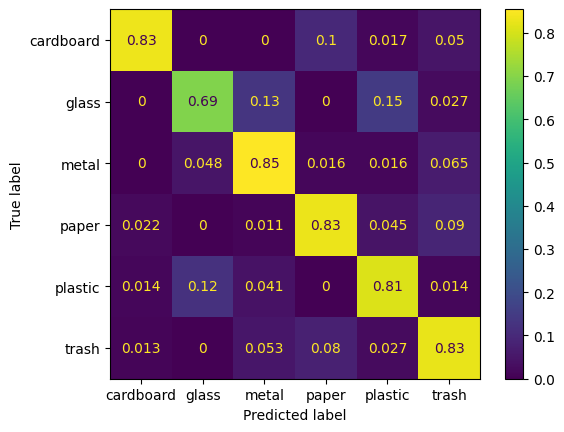

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.show()

## EfficientNetB0

EfficientNetB0 is a pretrained convolutional neural network (CNN) architecture designed to give high accuracy with fewer parameters and less computation compared to traditional models like ResNet or VGG.

In [137]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten
from tensorflow.keras.optimizers import Adam, Adadelta

In [138]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 18s 1us/step


In [139]:
base_model.trainable = False  # freeze base

In [142]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

In [144]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [145]:
# train model

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.1696 - loss: 1.8077 - val_accuracy: 0.2055 - val_loss: 1.7855
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.1908 - loss: 1.7935 - val_accuracy: 0.2055 - val_loss: 1.7857
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.1997 - loss: 1.7898 - val_accuracy: 0.2055 - val_loss: 1.7831
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.1898 - loss: 1.7894 - val_accuracy: 0.2055 - val_loss: 1.7834
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.1953 - loss: 1.7882 - val_accuracy: 0.2055 - val_loss: 1.7843
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.1765 - loss: 1.7883 - val_accuracy: 0.2055 - val_loss: 1.7849
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.2046 - loss: 1.7873 - val_accuracy: 0.2055 - val_loss: 1.7837
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.1878 - loss: 1.7869 - val_accuracy: 0.2055 - val_loss

In [146]:
train_loss, train_acc = model.evaluate(X_val, y_val)

train_acc


14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.2055 - loss: 1.7833


0.20554272830486298

### save the model

In [152]:
model.save('efficientnetb0_model.keras')

In [29]:
from tensorflow.keras.models import load_model

model_4 = load_model('efficientnetb0_model.keras')

In [154]:
test_loss, test_acc = model_4.evaluate(X_test, y_test)

test_acc

14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 998ms/step - accuracy: 0.2051 - loss: 1.7834


0.20506912469863892

In [155]:
y_pred_probs = model_4.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step 


In [151]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

   cardboard       0.00      0.00      0.00        60
       glass       0.00      0.00      0.00        75
       metal       0.00      0.00      0.00        62
       paper       0.21      1.00      0.34        89
     plastic       0.00      0.00      0.00        73
       trash       0.00      0.00      0.00        75

    accuracy                           0.21       434
   macro avg       0.03      0.17      0.06       434
weighted avg       0.04      0.21      0.07       434



c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

## InceptionV3

In [157]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten
from tensorflow.keras.optimizers import Adam, Adadelta

In [158]:
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 43s 0us/step


In [159]:
base_model.trainable = False  # freeze pretrained layers

In [160]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

In [161]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [162]:
# train model

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 278s 4s/step - accuracy: 0.3124 - loss: 1.7788 - val_accuracy: 0.5727 - val_loss: 1.2411
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 272s 4s/step - accuracy: 0.5522 - loss: 1.2123 - val_accuracy: 0.6674 - val_loss: 0.9875
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 249s 4s/step - accuracy: 0.6312 - loss: 1.0225 - val_accuracy: 0.6905 - val_loss: 0.8616
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.6708 - loss: 0.9059 - val_accuracy: 0.7136 - val_loss: 0.8065
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 208s 3s/step - accuracy: 0.7014 - loss: 0.8246 - val_accuracy: 0.7206 - val_loss: 0.7525
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.7410 - loss: 0.7258 - val_accuracy: 0.7229 - val_loss: 0.7245
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.7528 - loss: 0.6788 - val_accuracy: 0.7298 - val_loss: 0.6938
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.7781 - loss: 0.6257 - val_accuracy: 0.7529 - v

In [163]:
train_loss, train_acc = model.evaluate(X_val, y_val)

train_acc

14/14 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.7644 - loss: 0.6458


0.7644341588020325

### save the model

In [164]:
model.save('inceptionv3.keras')

In [16]:
from tensorflow.keras.models import load_model

model_5 = load_model('inceptionv3.keras')

In [17]:
test_loss, test_acc = model_5.evaluate(X_test, y_test)

test_acc

14/14 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.7926 - loss: 0.5728


0.7926267385482788

In [18]:
y_pred_probs = model_5.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

   cardboard       0.79      0.90      0.84        60
       glass       0.76      0.80      0.78        75
       metal       0.83      0.73      0.78        62
       paper       0.91      0.75      0.82        89
     plastic       0.72      0.74      0.73        73
       trash       0.76      0.85      0.81        75

    accuracy                           0.79       434
   macro avg       0.80      0.80      0.79       434
weighted avg       0.80      0.79      0.79       434



In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, normalize='true')

print(pd.DataFrame(cm, index = classes, columns=classes))

           cardboard     glass     metal     paper   plastic     trash
cardboard   0.900000  0.016667  0.000000  0.033333  0.000000  0.050000
glass       0.000000  0.800000  0.066667  0.000000  0.133333  0.000000
metal       0.016129  0.048387  0.725806  0.016129  0.096774  0.096774
paper       0.134831  0.000000  0.000000  0.752809  0.022472  0.089888
plastic     0.000000  0.191781  0.027397  0.000000  0.739726  0.041096
trash       0.013333  0.013333  0.026667  0.053333  0.040000  0.853333


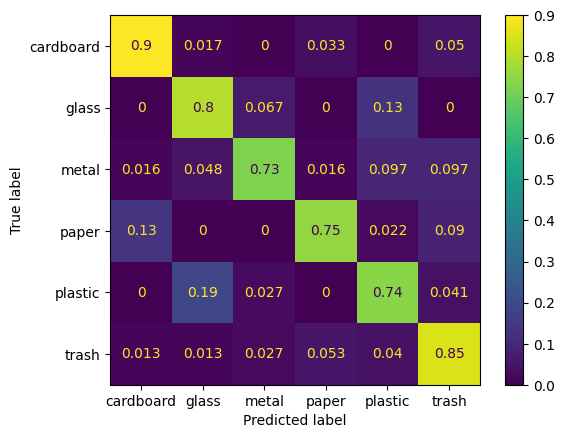

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.show()

# predict model_3 

In [ ]:
import cv2
import numpy as np


img = cv2.imread("./image/images_8.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0

# img = np.expand_dims(img, axis=0)  # shape (1, 224, 224, 3)
pred = model_3.predict(img.reshape(1, 224, 224, 3))

# prediction = model.predict(img)
class_id = np.argmax(pred)

classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print('pred:', pred, '\nclass_id:', class_id, "\nPredicted:", classes[class_id])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
pred: [[0.03424719 0.05975625 0.18262736 0.5929973  0.03919135 0.09118051]] 
class_id: 3 
Predicted: paper


In [ ]:
pred = model_3.predict(X_test[y_test==3][2].reshape(1, 224, 224, 3))

# prediction = model.predict(img)
class_id = np.argmax(pred)

classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print('pred:', pred, '\nclass_id:', class_id, "\nPredicted:", classes[class_id])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
pred: [[0.02257703 0.03351308 0.11037277 0.7300168  0.02610812 0.07741217]] 
class_id: 3 
Predicted: paper


In [7]:
# import matplotlib.pyplot as plt

# plt.imshow(X_test[y_test==3][2])
# plt.show